## Module 3 — Pattern / Text Mining

**Initial task description (Module 3 perspective):** 
Building upon our structural refinements in modules 1 and 2, our third analysis phase shifts focus from how we formally define "listening contexts" (clustering) to how we can exploit them (recommendations). In the previous phases, our evaluation pipeline measured cluster quality using Collaborative Filtering. Although a clear-cut solution, this method is notoriously susceptible to data sparsity (Banerjee, 2024), and estimates preferences based on general alignment, which could miss the strict thematic combinations that characterize music.

To address this limitation, we pivot to Pattern Mining. By applying frequent itemset mining and association rules internally within our established clusters, we can extract co-occurrence patterns that allow use to recommend tracks based on deterministic relationships rather than generalized user similarity. While pattern mining is generally even more vulnerable to sparsity than CF, executing it within our topologically dense clusters raises local support, allowing us to capture localized rules that would be invisible at a global scale. As pattern mining prioritizes precision over broad coverage, we integrate our original Collaborative Filtering model as a dynamic fallback mechanism. Ultimately, this approach investigates a core behavioural question: within a cohesive community, is human musical curation better predicted by exact programmatic track associations, or by generalized socio-musical alignment?

### Reproducibility and Setup


In [1]:
# prelims
import pandas as pd
import os
from evaluation.evaluator import eval
from pattern_mining.rules.FPGrowGenerator import FPGrowthGenerator
from notebook_helper import compare_results 

In [2]:
# chore, load vars which we need for analysis
# load the dataframe 
from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
df = pd.read_parquet(FULLY_PROCESSED_PARQUET)
# load the tfidf matrix, unique texts and vectorizer for later use in part 2-3
from clustering.tf_idf_analysis.tf_idf_analysis import load_tfidf_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_cache_dir = "data/tfidf_cache"
tfidf_matrix, unique_texts, vectorizer = load_tfidf_matrix(tfidf_cache_dir, df, TfidfVectorizer)

[INFO] Loading cached, cleaned TF-IDF matrix and unique texts...
[INFO] Loaded TF-IDF matrix shape: (84696, 5678)


In [3]:
# We would like to evaluate SVDKMeans, on both pure CF and hybrid
svd_kmeans_cluster_col = "svd200_kmeans_55"
hybrid_output_dir = "evaluation/reports/Hybrid_FPGrowth_CF"

### Algorithmic Selection 
We have chosen FP-Growth specifically to execute this mining process due to its superior efficiency compared to the standard Apriori method. 
- Utilizing an FP-tree it stores a compressed representation of the transaction database, reducing memory overhead during the mining process. 
- By mining suffixes bottom-up through conditional FP-trees, the algorithm ensures that once the thresholds are defined, the rules are extrated with optimal time complexity relative to the data.


### Hyperparameter Selection
The effectiveness of the association rule mining implementation relies on the calibration of two primary hyperparameters, minimum support and minimum confidence. These parameters acts as a statistical filter to ensure that only the most robust and predictive patterns are promoted to the hybrid recommendation set. 
 

#### Minimum Support (0.015)
Support defines the global frequency of an itemset (a combination of tracks) within a specific cluster dataset. we established a threshold of 1.5% for the following reasons.
- This particular threshold allows the FP-Growth algorithm to prune (limit) the search space of $2^d$ potential combinations efficiently, preventing the "combinatorial explosion" that occurs when dealing with high-dimensionality playlist data. Effectively decreasing the computing time. 
- Setting the *minsup* at 0.015 ensures that the engine ignores stochastic noise (track pairings that appear together purely by chance) and instead focuses on patterns that represent a consistent sub-trend within the cluster's musical community. 


#### Minimum Confidence (0.30)
Confidence measures the conditional probability of a rule, determining the likelihood that a user will listen to track *Y* given that their playlist already contains track *X*. We selected a 30% threshold based on several factors.
- We wanted a threshold which ensures that every rule generated has a statistically significant "hit rate" without being so restrictive that it only captures obvious associations. 
- We are trying to avoid the "Album Effect" which comes from setting confidence too high, ending up in capturing redundant associations, such as different tracks from the same album. 

### Rule Creation and Analysis (FP-Growth)


CALCULATING SILHOUETTE SCORE

CALCULATING SILHOUETTE SCORE FOR svd200_kmeans_55
-> Final Silhouette Score (svd200_kmeans_55): 0.1148

Processing Cluster 32.0...
Number of samples in Cluster 32.0: 2849225
  -> Successfully split 11016 users into train/test sets.
[FP-Growth | Cluster 32.0] Checking master Parquet...
[FP-Growth | Cluster 32.0] Mining new rules...
[FP-Growth] Generated 0 rules based on support and confidence.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 32.0 ---
Items from Rules: 0 (0.0%)
Items from CF:    67745256 (100.0%)
Coverage: 0/200 users received rule-based tips.

Processing Cluster 12.0...
Number of samples in Cluster 12.0: 598278
  -> Successfully split 6266 users into train/test sets.
[FP-Growth | Cluster 12.0] Checking master Parquet...
[FP-Growth | Cluster 12.0] Mining new rules...
[FP-Growth] Generated 0 rules based on support and confidence.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 12.0 ---
Items from Rules: 0 (0.0%)
Items from CF:    8221603 (100.0%)
Coverage: 0/200 users received rule-based tips.

Processing Cluster 2.0...
Number of samples in Cluster 2.0: 181794
  -> Successfully split 3129 users into train/test sets.
[FP-Growth | Cluster 2.0] Checking master Parquet...
[FP-Growth] Loaded 100 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 2.0 ---
Items from Rules: 112 (0.0%)
Items from CF:    1901564 (100.0%)
Coverage: 24/200 users received rule-based tips.

Processing Cluster 4.0...
Number of samples in Cluster 4.0: 178788
  -> Successfully split 685 users into train/test sets.
[FP-Growth | Cluster 4.0] Checking master Parquet...
[FP-Growth] Loaded 941 rules from Parquet in 0.04s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 4.0 ---
Items from Rules: 415 (0.0%)
Items from CF:    5916564 (100.0%)
Coverage: 54/200 users received rule-based tips.

Processing Cluster 6.0...
Number of samples in Cluster 6.0: 166844
  -> Successfully split 1557 users into train/test sets.
[FP-Growth | Cluster 6.0] Checking master Parquet...
[FP-Growth] Loaded 1719 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...


...


--- Trace for Cluster 38.0 ---
Items from Rules: 70 (0.2%)
Items from CF:    40393 (99.8%)
Coverage: 17/200 users received rule-based tips.

Processing Cluster 50.0...
Number of samples in Cluster 50.0: 17307
  -> Successfully split 329 users into train/test sets.
[FP-Growth | Cluster 50.0] Checking master Parquet...
[FP-Growth] Loaded 1618 rules from Parquet in 0.04s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 50.0 ---
Items from Rules: 1588 (0.3%)
Items from CF:    487066 (99.7%)
Coverage: 98/200 users received rule-based tips.

Processing Cluster 51.0...
Number of samples in Cluster 51.0: 16048
  -> Successfully split 639 users into train/test sets.
[FP-Growth | Cluster 51.0] Checking master Parquet...
[FP-Growth] Loaded 5509 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 51.0 ---
Items from Rules: 607 (1.7%)
Items from CF:    34785 (98.3%)
Coverage: 72/200 users received rule-based tips.

Processing Cluster 48.0...
Number of samples in Cluster 48.0: 12156
  -> Successfully split 598 users into train/test sets.
[FP-Growth | Cluster 48.0] Checking master Parquet...
[FP-Growth] Loaded 2418 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 48.0 ---
Items from Rules: 337 (2.3%)
Items from CF:    14538 (97.7%)
Coverage: 56/200 users received rule-based tips.

Processing Cluster 35.0...
Number of samples in Cluster 35.0: 11732
  -> Successfully split 381 users into train/test sets.
[FP-Growth | Cluster 35.0] Checking master Parquet...
[FP-Growth] Loaded 74578 rules from Parquet in 0.09s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 35.0 ---
Items from Rules: 2244 (8.0%)
Items from CF:    25905 (92.0%)
Coverage: 63/200 users received rule-based tips.

Saving metrics to evaluation/reports/Hybrid_FPGrowth_CF/evaluation_metrics_svd200_kmeans_55.txt...
Rule activation stats saved to evaluation/reports/Hybrid_FPGrowth_CF/rule_activation_stats.json

Generating evaluation graphs...
Graph successfully saved as 'evaluation/reports/Hybrid_FPGrowth_CF/f01_comparison.png'


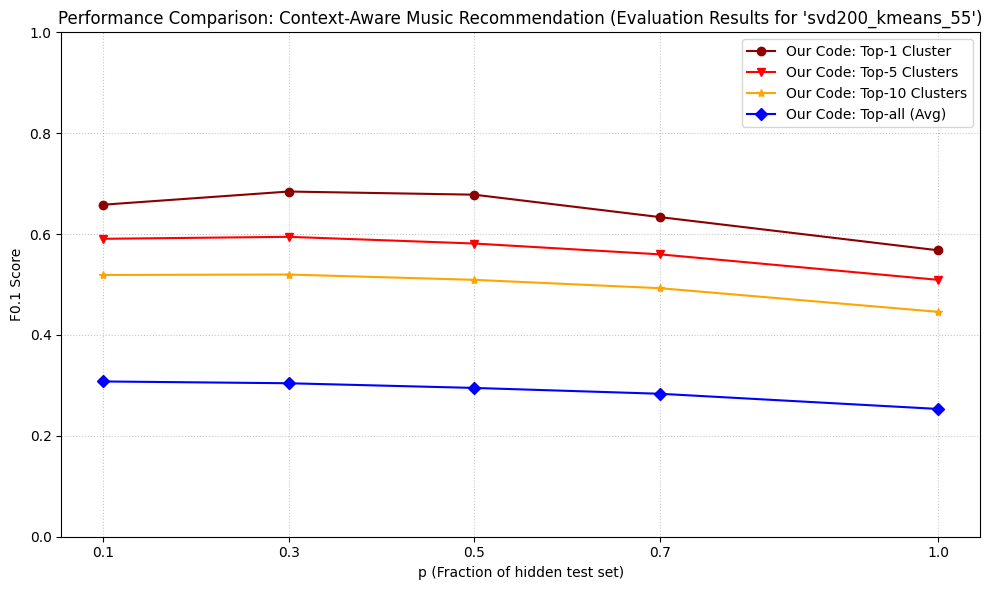


PLOTTING CLUSTER DISTRIBUTION
-> Distribution graph saved successfully to: evaluation/reports/Hybrid_FPGrowth_CF/cluster_distribution.png


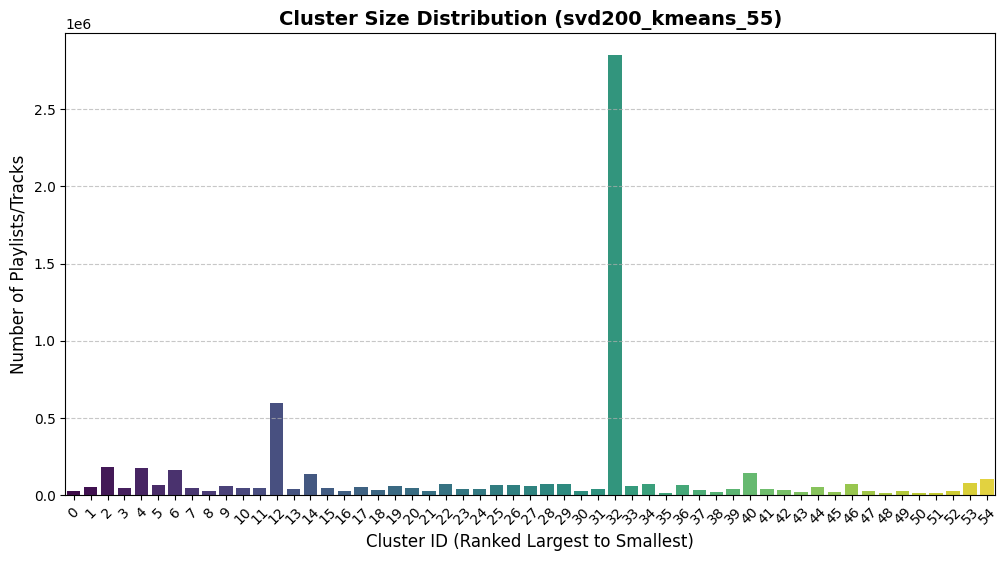


=== FINAL EVALUATION AVERAGES ===
Top-1 Average:   [np.float64(0.6582), np.float64(0.6844), np.float64(0.6781), np.float64(0.6337), np.float64(0.5678)]
Top-5 Average:   [np.float64(0.5907), np.float64(0.5946), np.float64(0.5813), np.float64(0.5599), np.float64(0.5093)]
Top-all Average: [np.float64(0.3078), np.float64(0.3043), np.float64(0.295), np.float64(0.2834), np.float64(0.2533)]


In [4]:
# Defining the rule generator with desired parameters
fp_generator = FPGrowthGenerator(
    min_support_pct=0.015, # rule must appear in at least x% of transactions (playlists) to be considered
    min_confidence=0.30, 
    config_name="hybrid_test_01"
)

# Running the evaluation for the hybrid approach, which will also trigger rule mining and evaluation within the eval function

# if results already made, then skip
if os.path.exists(hybrid_output_dir):
    print(f"Results already exist in {hybrid_output_dir}, skipping evaluation.")
else:
    eval(
        df=df, 
        cluster_col=svd_kmeans_cluster_col, 
        unique_texts=unique_texts, 
        tfidf_matrix=tfidf_matrix, 
        output_dir=hybrid_output_dir,
        rule_generator=fp_generator, # trigger rule mining and evaluation within the eval function
    )

In [5]:
# Now we can analyze the generated rules and their relationship to the evaluation metrics
from evaluation.rule_analysis_helper import AssociationRuleAnalyzer
analyzer = AssociationRuleAnalyzer()

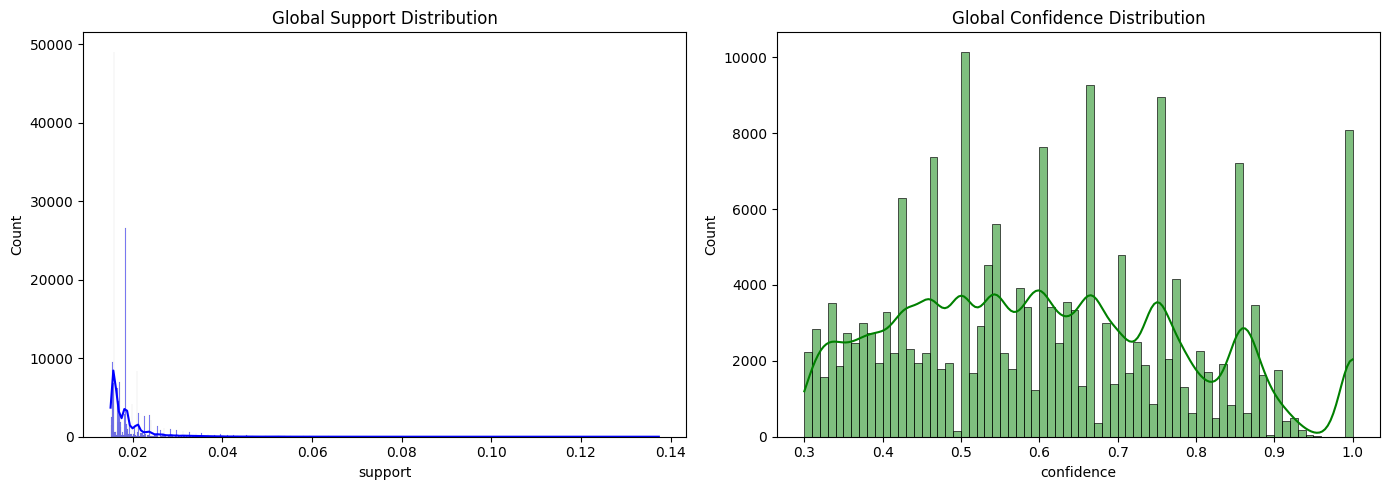

In [6]:
analyzer.plot_support_confidence_distributions()

The global support and confidence distributions reveal an important asymmetry within the generated rule space. While the confidence scores remain broadly distributed across moderate-to-high values, the support distribution is overwhelmingly concentrated near the minimum threshold. This indicates that many mined associations appear statistically reliable despite being derived from extremely sparse co-occurrence patterns. Consequently, confidence alone becomes an insufficient indicator of recommendation quality within high-dimensional playlist environments, as locally consistent but weakly supported rules may fail to generalize beyond niche listening contexts. 

### Evaluation

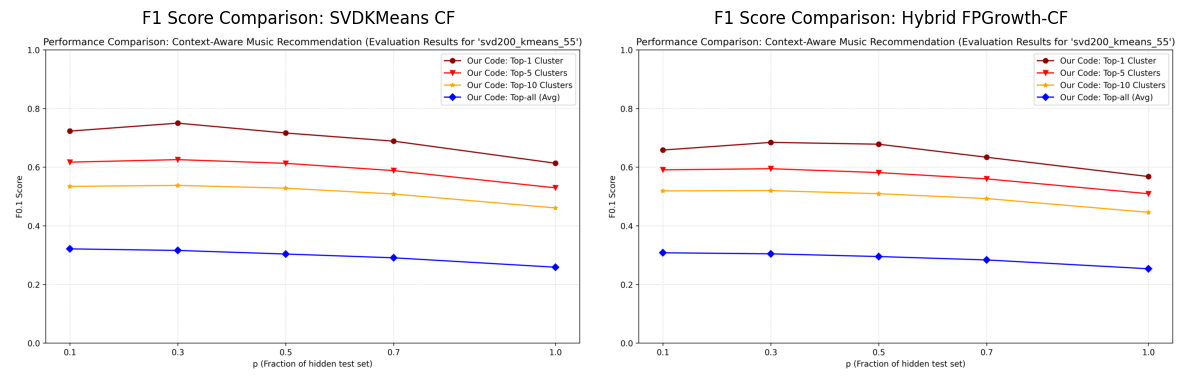

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Plotting the results
cf_f_score_plot = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/f01_comparison.png"
rules_cf_f_score_plot = "evaluation/reports/Hybrid_FPGrowth_CF/f01_comparison.png"
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(mpimg.imread(cf_f_score_plot))
ax[0].set_title("F1 Score Comparison: SVDKMeans CF")
ax[0].axis('off')

ax[1].imshow(mpimg.imread(rules_cf_f_score_plot))
ax[1].set_title("F1 Score Comparison: Hybrid FPGrowth-CF")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Better more detailed viewing
hybrid_txt = "evaluation/reports/Hybrid_FPGrowth_CF/evaluation_metrics_svd200_kmeans_55.txt"
pure_cf_txt = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/evaluation_metrics_svd200_kmeans_55.txt"

if os.path.exists(pure_cf_txt) and os.path.exists(hybrid_txt):
    flat_df, table = compare_results(pure_cf_txt, hybrid_txt)
    display(table)
else:
    print("Check your file paths; one or both reports are missing.")

#### Overall Trends
A comparative analysis of the F0.1 scores across a varying ($p$) reveals a marginal, yet systematic, performance reduction in the hybrid model compared to the pure collaborative filtering (CF) baseline. As evidenced in the **Delta** values, the integration of FP-Growth association rules resulted in a consistent decline in precision across the cluster tiers. Rather than boosting the performance of the baseline, injecting these deterministic patterns actually handicapped the recommender's ability to retrieve relevant tracks.



#### Dilution Investigation
Given the extremely marginal difference in performance compared to the baseline, we initially hypothesized that the generated FP-Growth rules were rarely being triggered, causing the system to predominantly default to the collaborative filtering mechanism. Further investigation of the rule application rate confirmed this limitation (See below histogram). 


AVERAGE RULE CONTRIBUTION RATIO: 0.0032
Histogram saved to evaluation/reports/Hybrid_FPGrowth_CF/rule_contribution_histogram.png


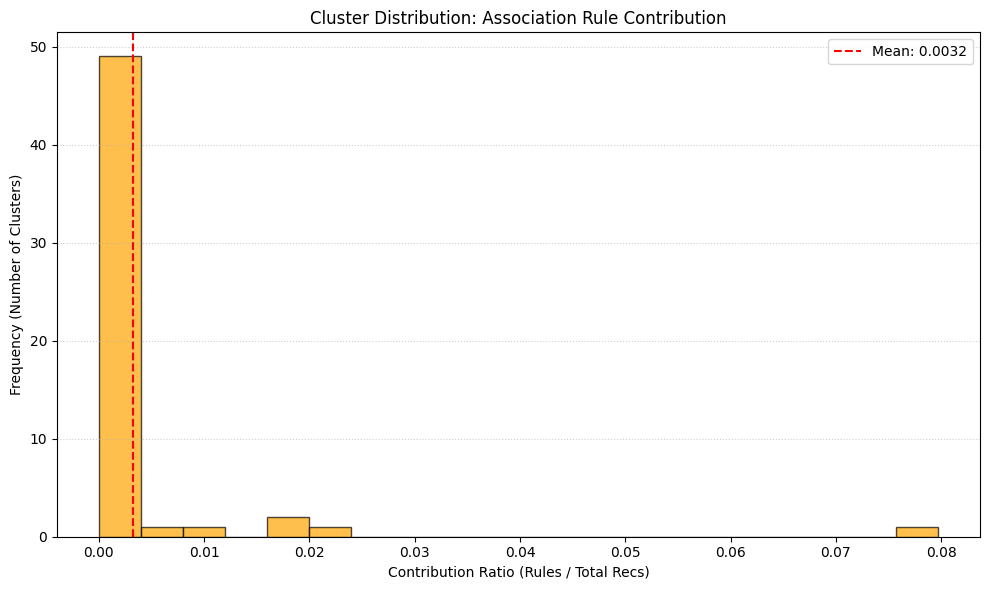

In [9]:
analyzer.plot_rule_contribution_histogram(stats_json_path="evaluation/reports/Hybrid_FPGrowth_CF/rule_activation_stats.json", output_path="evaluation/reports/Hybrid_FPGrowth_CF/rule_contribution_histogram.png")

The above mean value association rule contribution plot confirms that the rules only contribute very little compared to CF. This presents a significant structural paradox for hyperparameter tuning, perfectly illustrated by the **Support vs Confidence** distribution plotted below:

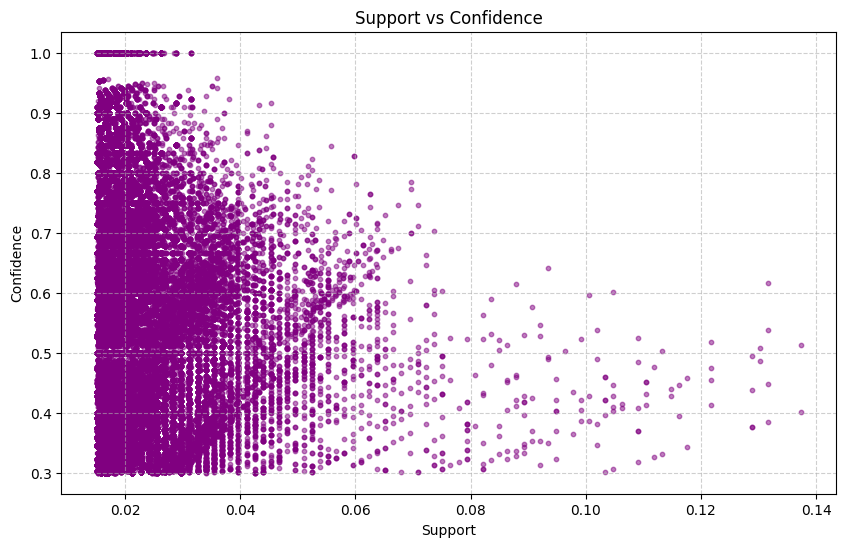

In [10]:
analyzer.plot_support_vs_confidence()

- **Decreasing Thresholds:** The massive, dense vertical wall of rules anchored immediately at our minimum boundaries ($Support=0.015, Confidence=0.30$) shows that the vast majority of mined patterns are borderline cases. If we decrease these thresholds to force the rules to trigger more frequently, we would absorb an exponential amount of stochastic noise from the bottom-left, injecting weak associations that actively degrade the recommendation quality.
- **Increasing Thresholds:** Conversely, looking outward to the top-right of the scatter plot reveals a drastic sparsity. If we increase the thresholds to ensure only more high-quality rules are utilized, the available rule pool practically evaporates, diluting the mined recommendations even further. 

Ultimately, this indicates that pattern mining is inherently constrained by the quality of the underlying partitions. For a hybrid rule-based system to significantly outperform generalized collaborative filtering, the base clusters must exhibit exceptionally high intra-cluster song cohesion, such as the strict thematic density observed in Cluster 7 ($\{\text{Little Drummer Boy}\} \Rightarrow \{\text{The First Noel}\}, \text{confidence} = 1.0$). Without such rigid semantic boundaries, absolute association rules fail to generalize effectively across sparse user playlists compared to probabilistic alignment. We hypothesize that the method would perform significantly better if the clusters were based on direct track co-occurrences, rather than the semantic text of playlist titles. By clustering based on the actual tracks contained within the playlists, we would inherently guarantee the baseline item density required for frequent itemset mining to thrive.

#### Refining Results (Filtering rules)
The hyperparameter stalemate described above highlights a fundamental flaw in relying solely on Support and Confidence: they inherently bias the pattern mining algorithm toward global clustering trends, forcing it to compete directly with Collaborative Filtering on CF's home turf. 

Collaborative filtering already excels at capturing broad, probabilistic popularity alignment. If we tune our FP-Growth rules purely for high support and confidence, we end up generating highly popular associations that are effectively redundant or damaging to the CF baseline. To make the hybrid model valuable, the association rules shouldn't try to replicate CF; they should complement it by capturing the relationships that generalized probabilistic models miss.

To do this we suggest looking at **Lift**. In music datasets, global hits (e.g., a Taylor Swift or The Weeknd track) act as statistical magnets. Because their "Support($B$)" is naturally high, the "Confidence($A \rightarrow B$)" will almost always be high, regardless of what item $A$ is. Lift corrects this by dividing the Confidence by the probability of $B$ occurring anyway. It is calculated as the ratio of the observed support to the expected support if the two items were completely independent. 
$$\text{(eq 1)}: \text{Lift}(A \rightarrow B) = \frac{\text{Confidence}(A \rightarrow B)}{\text{Support($B$})}.$$
The value of Lift is generally interpreted against a baseline of 1:
- Lift > 1 means that there is a positive correlation. 
- Lift = 1 implies no relationship between A and B.

The average lift across all cluster is printed below.


Average Lift across all clusters: 17.8704


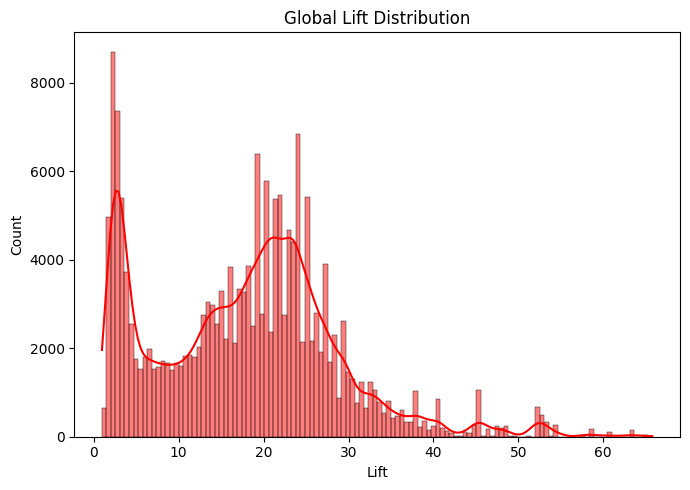

In [11]:
analyzer.print_average_lift()
analyzer.plot_lift_distribution()

Looking at the global lift distribution, the most critical phenomenon is the spike anchored at the far left edge of the graph. This concentration of rules barely break a lift of 1.0 (between 1 and 3). These rules represent slight positive correlations that are valid under our Support/Confidence thresholds, but are practically redundant for discovery. They indicate weak, popularity-driven associations, exactly the type of broad, generalized recommendations that our Collaborative Filtering baseline already excels at providing. Allowing these low-lift rules into the hybrid engine suffocates the recommendation pool with "safe" hits, entirely defeating the purpose of integrating Pattern Mining.

To leverage this, we pass `refine_results=True` to our evaluation pipeline, altering the hybrid architecture:
1. **Strict Lift-Based Filtering ($\text{Lift} > 2.0$):** We shear off the massive spike of rules hovering near 1.0. This forces the engine to ignore overlapping popularity logic and isolates tracks that share a definitively unique positive correlation. 
2. **Dynamic Quota Allocation:** Because high-lift sequences can sometimes chain together, we cap rule-based recommendations to a maximum of 20% of the output pool. The remaining 80% dynamically falls back to CF.
3. **Confidence Sorting:** Within the surviving pool of strong-lift rules, we sort by confidence to ensure we maximize our hit rate among these unique discoveries before falling back to the CF baseline.

**Evaluating the Trade-off:**
It is crucial to state that we do not expect this strict Lift filtering to improve our $F_{0.1}$ score. However, a recommender system optimized solely for safe guesses fails at true music discovery. By using Lift to forcefully inject specific, niche associations into the recommendation pool, we are trading a fraction of "guaranteed" offline precision in exchange for structural diversity. While the $F_{0.1}$ score may dip, conceptually, this approach perhaps is destined for more real world success.


CALCULATING SILHOUETTE SCORE

CALCULATING SILHOUETTE SCORE FOR svd200_kmeans_55
-> Final Silhouette Score (svd200_kmeans_55): 0.1148

Processing Cluster 32.0...
Number of samples in Cluster 32.0: 2849225
  -> Successfully split 11016 users into train/test sets.
[FP-Growth | Cluster 32.0] Checking master Parquet...
[FP-Growth | Cluster 32.0] Mining new rules...
[FP-Growth] Generated 0 rules based on support and confidence.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 32.0 ---
Items from Rules: 0 (0.0%)
Items from CF:    67337599 (100.0%)
Coverage: 0/200 users received rule-based tips.

Processing Cluster 12.0...
Number of samples in Cluster 12.0: 598278
  -> Successfully split 6266 users into train/test sets.
[FP-Growth | Cluster 12.0] Checking master Parquet...
[FP-Growth | Cluster 12.0] Mining new rules...
[FP-Growth] Generated 0 rules based on support and confidence.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 12.0 ---
Items from Rules: 0 (0.0%)
Items from CF:    8288333 (100.0%)
Coverage: 0/200 users received rule-based tips.

Processing Cluster 2.0...
Number of samples in Cluster 2.0: 181794
  -> Successfully split 3129 users into train/test sets.
[FP-Growth | Cluster 2.0] Checking master Parquet...
[FP-Growth] Loaded 100 rules from Parquet in 0.04s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 2.0 ---
Items from Rules: 96 (0.0%)
Items from CF:    1905471 (100.0%)
Coverage: 22/200 users received rule-based tips.

Processing Cluster 4.0...
Number of samples in Cluster 4.0: 178788
  -> Successfully split 685 users into train/test sets.
[FP-Growth | Cluster 4.0] Checking master Parquet...
[FP-Growth] Loaded 941 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 4.0 ---
Items from Rules: 422 (0.0%)
Items from CF:    5903069 (100.0%)
Coverage: 57/200 users received rule-based tips.

Processing Cluster 6.0...
Number of samples in Cluster 6.0: 166844
  -> Successfully split 1557 users into train/test sets.
[FP-Growth | Cluster 6.0] Checking master Parquet...
[FP-Growth] Loaded 1719 rules from Parquet in 0.04s.
  -> Generating recommendations & evaluating 200 sampled users...


...


--- Trace for Cluster 38.0 ---
Items from Rules: 80 (0.2%)
Items from CF:    45625 (99.8%)
Coverage: 18/200 users received rule-based tips.

Processing Cluster 50.0...
Number of samples in Cluster 50.0: 17307
  -> Successfully split 329 users into train/test sets.
[FP-Growth | Cluster 50.0] Checking master Parquet...
[FP-Growth] Loaded 1618 rules from Parquet in 0.04s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 50.0 ---
Items from Rules: 1458 (0.3%)
Items from CF:    465202 (99.7%)
Coverage: 89/200 users received rule-based tips.

Processing Cluster 51.0...
Number of samples in Cluster 51.0: 16048
  -> Successfully split 639 users into train/test sets.
[FP-Growth | Cluster 51.0] Checking master Parquet...
[FP-Growth] Loaded 5509 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 51.0 ---
Items from Rules: 612 (1.8%)
Items from CF:    33890 (98.2%)
Coverage: 71/200 users received rule-based tips.

Processing Cluster 48.0...
Number of samples in Cluster 48.0: 12156
  -> Successfully split 598 users into train/test sets.
[FP-Growth | Cluster 48.0] Checking master Parquet...
[FP-Growth] Loaded 2418 rules from Parquet in 0.04s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 48.0 ---
Items from Rules: 342 (1.9%)
Items from CF:    17579 (98.1%)
Coverage: 58/200 users received rule-based tips.

Processing Cluster 35.0...
Number of samples in Cluster 35.0: 11732
  -> Successfully split 381 users into train/test sets.
[FP-Growth | Cluster 35.0] Checking master Parquet...
[FP-Growth] Loaded 74578 rules from Parquet in 0.09s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 35.0 ---
Items from Rules: 2263 (7.7%)
Items from CF:    27092 (92.3%)
Coverage: 67/200 users received rule-based tips.

Saving metrics to evaluation/reports/Hybrid_FPGrowth_CF/refine_results/evaluation_metrics_svd200_kmeans_55.txt...
Rule activation stats saved to evaluation/reports/Hybrid_FPGrowth_CF/refine_results/rule_activation_stats.json

Generating evaluation graphs...
Graph successfully saved as 'evaluation/reports/Hybrid_FPGrowth_CF/refine_results/f01_comparison.png'


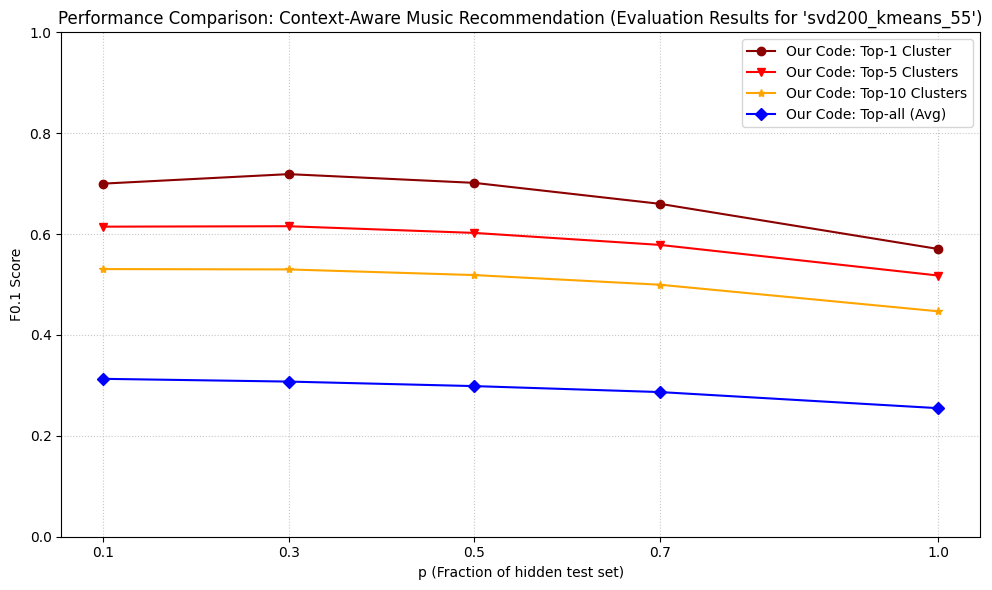


PLOTTING CLUSTER DISTRIBUTION
-> Distribution graph saved successfully to: evaluation/reports/Hybrid_FPGrowth_CF/refine_results/cluster_distribution.png


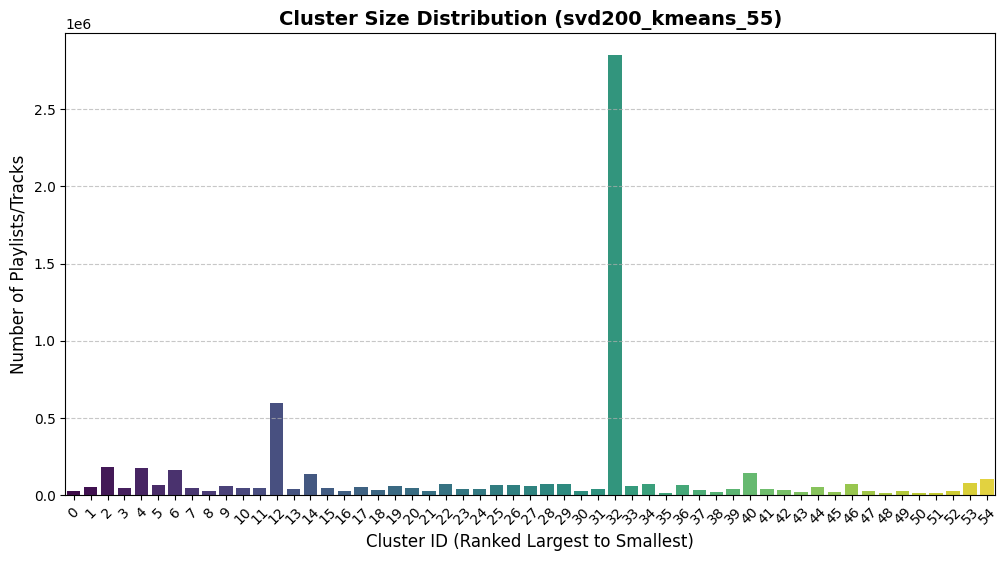


=== FINAL EVALUATION AVERAGES ===
Top-1 Average:   [np.float64(0.7), np.float64(0.7189), np.float64(0.7016), np.float64(0.66), np.float64(0.5705)]
Top-5 Average:   [np.float64(0.6147), np.float64(0.6156), np.float64(0.6023), np.float64(0.5786), np.float64(0.5178)]
Top-all Average: [np.float64(0.313), np.float64(0.3076), np.float64(0.2986), np.float64(0.2868), np.float64(0.2549)]


In [12]:
# el muchacho betterino
refined_output_dir = hybrid_output_dir + "/refine_results"
if os.path.exists(refined_output_dir):
    print(f"Refined results already exist in {refined_output_dir}, skipping re-evaluation.")
else:
     eval(df=df,
          cluster_col=svd_kmeans_cluster_col, 
          unique_texts=unique_texts, 
          tfidf_matrix=tfidf_matrix, 
          output_dir=refined_output_dir,
          rule_generator=fp_generator,
          refine_results=True, 
     )

In [13]:
# Better more detailed viewing
hybrid_txt = "evaluation/reports/Hybrid_FPGrowth_CF/refine_results/evaluation_metrics_svd200_kmeans_55.txt"
pure_cf_txt = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/evaluation_metrics_svd200_kmeans_55.txt"

if os.path.exists(pure_cf_txt) and os.path.exists(hybrid_txt):
    flat_df, table = compare_results(pure_cf_txt, hybrid_txt)
    display(table)
else:
    print("Check your file paths; one or both reports are missing.")

Despite introducing refinement constraints based on Lift and confidence ranking, the hybrid recommender continued to underperform the pure collaborative filtering baseline across all evaluation depths and p-values. This result is particularly significant because the refinement stage aggressively filtered the association space to retain only statistically strong rules with reduced popularity bias. Consequently, the negative performance deltas suggest that the limitation does not primarily originate from noisy or low-quality rules, but rather from the structural sparsity of the underlying playlist representation itself. Although high-lift rules indicate meaningful local relationships between tracks, these associations are often too specific to small subsets of playlists to consistently improve overall recommendation quality. 

Collaborative filtering, by contrast, can aggregate weak similarity signals across many users without requiring explicit repeated co-occurrences between tracks. The findings therefore indicate that the effectiveness of association-rule mining is fundamentally constrained by the density and cohesiveness of the item space from which the rules are derived.